In [236]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn import metrics
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, GridSearchCV
from sklearn.model_selection import KFold
from sklearn import linear_model
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate, cross_val_predict, KFold
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Reading in data and separating features from targets

In [200]:
data = pd.read_csv('data.csv')

In [201]:
data

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,soltype,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassprov,pl_dens,pl_denserr1,pl_denserr2,pl_denslim,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbincllim,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_lum,st_lumerr1,st_lumerr2,st_lumlim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_dens,st_denserr1,st_denserr2,st_denslim,ra,dec,sy_bmag,sy_bmagerr1,sy_bmagerr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_tmag,sy_tmagerr1,sy_tmagerr2
0,G 9-40 b,G 9-40,1,1,1,Transit,Published Confirmed,0,5.745998,2.000000e-06,-2.000000e-06,0,0.04180,0.00064,-0.00064,0,1.900000,0.065000,-0.065000,0,4.000000,0.630000,-0.630000,0,Mass,3.200000,0.630000,-0.580000,0,0.00000,NaN,NaN,0,6.27,0.19,-0.19,0,440.6,7.6,-7.6,0,89.030,0.100,-0.100,0,3395.0,51.0,-51.0,0,0.3026,0.0095,-0.0095,0,0.2952,0.0136,-0.0136,0,-0.07,0.16,-0.16,0,[Fe/H],-1.96019,0.00746,-0.00759,0,4.8400,0.0400,-0.040,0,1.620000,0.110000,-0.110000,0,134.718851,21.074796,15.477,0.079,-0.079,13.821,0.044,-0.044,12.73310,0.000440,-0.000440,11.521900,0.007395,-0.007395
1,GJ 367 b,GJ 367,1,1,3,Transit,Published Confirmed,0,0.321923,2.000000e-07,-2.000000e-07,0,0.00709,0.00027,-0.00027,0,0.699000,0.024000,-0.024000,0,0.633000,0.050000,-0.050000,0,Mass,10.200000,1.300000,-1.300000,0,0.06000,0.0700,-0.04000,0,579.00,57.00,-52.00,0,1365.0,32.0,-32.0,0,79.890,0.870,-0.850,0,3522.0,70.0,-70.0,0,0.4580,0.0130,-0.0130,0,0.4550,0.0110,-0.0110,0,-0.01,0.12,-0.12,0,[Fe/H],-1.53910,0.04153,-0.04260,0,4.7760,0.0260,-0.026,0,6.696675,0.620324,-0.549832,0,146.121464,-45.779016,11.617,0.034,-0.034,10.153,0.044,-0.044,9.15159,0.000650,-0.000650,8.031941,0.007430,-0.007430
2,GJ 3929 b,GJ 3929,1,1,2,Transit,Published Confirmed,0,2.616235,5.000000e-06,-5.000000e-06,0,0.02520,0.00050,-0.00050,0,1.090000,0.040000,-0.040000,0,1.750000,0.440000,-0.450000,0,Mass,7.300000,2.000000,-2.000000,0,0.00000,NaN,NaN,0,17.30,0.70,-0.70,0,568.0,6.0,-6.0,0,88.442,0.008,-0.008,0,3384.0,88.0,-88.0,0,0.3200,0.0100,-0.0100,0,0.3130,0.0270,-0.0220,0,-0.02,0.12,-0.12,0,[Fe/H],-1.96257,0.01948,-0.01624,0,4.8900,0.0500,-0.050,0,13.300000,1.100000,-1.100000,0,239.577568,35.408114,14.333,0.008,-0.008,12.675,0.023,-0.023,11.51090,0.000681,-0.000681,10.270500,0.007334,-0.007334
3,GJ 486 b,GJ 486,1,1,1,Radial Velocity,Published Confirmed,0,1.467121,3.100000e-07,-3.500000e-07,0,0.01714,0.00013,-0.00013,0,1.289000,0.019000,-0.014000,0,2.770000,0.076000,-0.073000,0,Mass,6.660000,0.230000,-0.290000,0,0.00086,0.0016,-0.00043,0,39.20,1.70,-1.60,0,696.3,7.2,-7.3,0,89.390,0.410,-0.420,0,3317.0,36.0,-37.0,0,0.3243,0.0044,-0.0034,0,0.3120,0.0070,-0.0069,0,-0.15,0.13,-0.12,0,[Fe/H],-1.93892,0.01738,-0.01771,0,4.9111,0.0068,-0.011,0,12.950000,0.250000,-0.500000,0,191.981531,9.749418,2.615,0.291,-0.291,11.390,0.100,-0.100,10.09400,0.000746,-0.000746,8.822300,0.007271,-0.007271
4,GPX-1 b,GPX-1,1,1,1,Transit,Published Confirmed,0,1.744579,8.000000e-06,-8.000000e-06,0,0.03380,0.00030,-0.00030,0,16.477202,1.120898,-1.120898,0,6261.219618,508.525451,-508.525451,0,Mass,8.222423,1.724056,-1.326197,0,0.00000,NaN,NaN,0,4650.00,370.00,-370.00,0,2300.0,48.0,-48.0,0,79.900,0.700,-0.600,0,7000.0,200.0,-200.0,0,1.5600,0.1000,-0.1000,0,1.6800,0.1000,-0.1000,0,0.35,0.10,-0.10,0,[Fe/H],0.72673,0.03143,-0.03388,0,4.2700,0.0500,-0.050,0,0.620324,0.140983,-0.140983,0,38.369165,56.025708,12.740,0.043,-0.043,12.316,0.069,-0.069,12.22280,0.000237,-0.000237,11.900400,0.009900,-0.009900
...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [202]:
# Selecting the features (many columns in the dataset are irrelevant)
features = data[['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_dens', 'pl_orbeccen', 'pl_insol', 'pl_orbincl', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_lum', 'st_logg', 'st_dens', 'sy_gaiamag']]

In [203]:
features.describe()

,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_insol,pl_orbincl,st_teff,st_rad,st_mass,st_met,st_lum,st_logg,st_dens,sy_gaiamag
count,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000
mean,26.062384,0.109960,8.585039,366.098931,6.394416,0.100242,535.245716,87.236883,5140.334123,1.062579,0.917720,0.087147,-0.294878,4.425159,2.818963,11.696176
std,109.155030,0.239531,5.546689,896.768425,37.961996,0.146157,808.387827,2.600513,1018.089878,0.541111,0.335303,0.212526,0.805461,0.293006,3.897519,1.928047
min,0.321923,0.007090,0.640000,0.070000,0.076000,0.000000,0.300000,76.010000,3096.000000,0.215900,0.184400,-0.460000,-2.420220,3.580000,0.072370,5.240200
25%,3.090276,0.038115,2.670500,8.860000,0.570000,0.000000,37.200000,86.190000,4227.000000,0.656200,0.670000,-0.064500,-0.889410,4.212000,0.620662,10.854200
50%,4.148047,0.052220,9.919948,112.000000,1.700000,0.059000,175.100000,88.110000,5510.000000,0.940000,0.939000,0.103000,-0.141460,4.435000,1.448000,12.033800
75%,9.138822,0.081100,12.632532,328.952401,3.475000,0.129500,782.500000,88.995000,5852.500000,1.426500,1.146000,0.239500,0.379940,4.630000,3.430000,12.600300
max,1047.835600,2.027000,19.952020,8899.195396,400.000000,0.920000,5300.000000,89.982000,7690.000000,2.879000,1.900000,0.790000,1.068190,5.200000,25.800000,15.909100


In [204]:
# Defining target
target = data['pl_eqt']
target.describe()

count     211.000000
mean     1058.151185
std       495.105702
min       206.000000
25%       656.000000
50%       971.000000
75%      1471.500000
max      2370.000000
Name: pl_eqt, dtype: float64

In [205]:
# Splitting train/test data for model
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

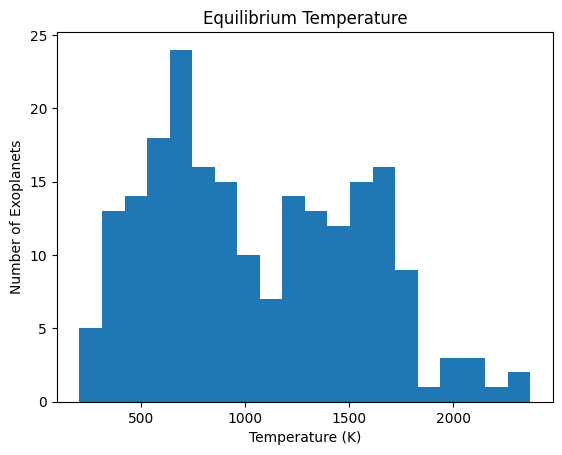

In [206]:
# Investigating the target values
plt.hist(data['pl_eqt'], bins=20)
plt.title('Equilibrium Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Number of Exoplanets')
plt.savefig('eqt_hist', bbox_inches='tight')

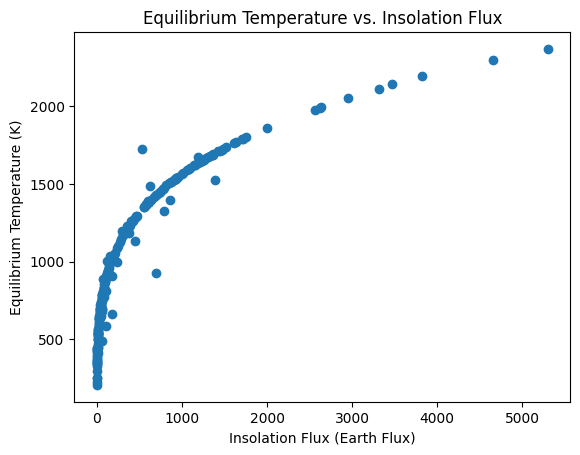

In [207]:
# The next four plots all examine some feature correlation relative to the target
plt.scatter(data['pl_insol'], data['pl_eqt'])
plt.title('Equilibrium Temperature vs. Insolation Flux')
plt.xlabel('Insolation Flux (Earth Flux)')
plt.ylabel('Equilibrium Temperature (K)')
plt.savefig('insol', bbox_inches='tight')

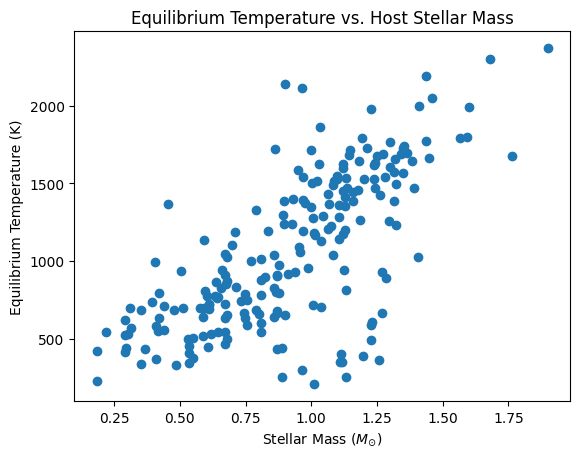

In [208]:
plt.scatter(data['st_mass'], data['pl_eqt'])
plt.title('Equilibrium Temperature vs. Host Stellar Mass')
plt.xlabel(r'Stellar Mass ($M_{\odot}$)')
plt.ylabel('Equilibrium Temperature (K)')
plt.savefig('st_mass', bbox_inches='tight')

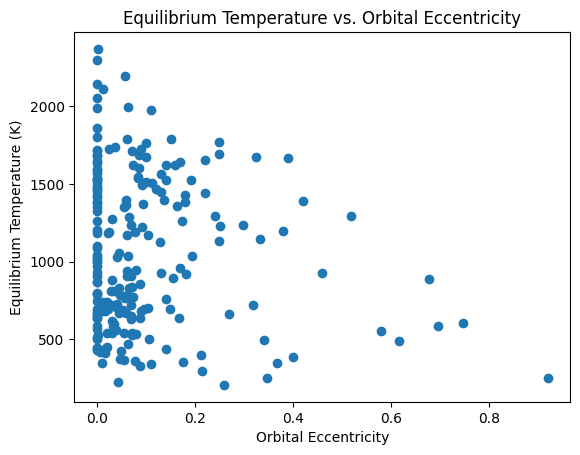

In [209]:
plt.scatter(data['pl_orbeccen'], data['pl_eqt'])
plt.title('Equilibrium Temperature vs. Orbital Eccentricity')
plt.xlabel('Orbital Eccentricity')
plt.ylabel('Equilibrium Temperature (K)')
plt.savefig('ecc', bbox_inches='tight')

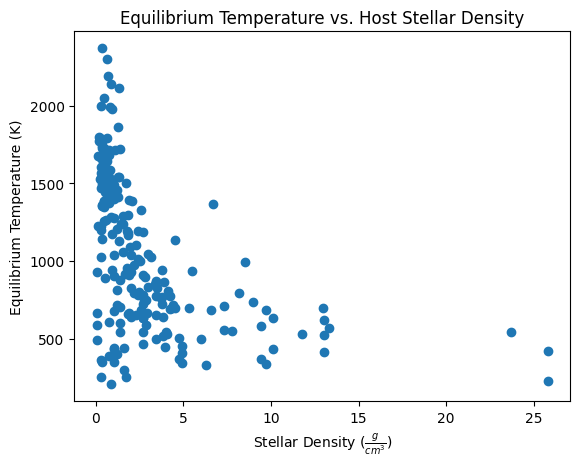

In [210]:
plt.scatter(data['st_dens'], data['pl_eqt'])
plt.title('Equilibrium Temperature vs. Host Stellar Density')
plt.xlabel(r'Stellar Density ($\frac{g}{cm^3}$)')
plt.ylabel('Equilibrium Temperature (K)')
plt.savefig('st_dens', bbox_inches='tight')

# Random Forest

In [211]:
# Build initial Random Forest model
model_RF = RandomForestRegressor(max_features=4, n_estimators=200)

In [212]:
# Evaluate initial R^2 results to see how the model performed
scores = cross_validate(model_RF, features, target, cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score=True)

print('Train R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(scores['train_score']), np.std(scores['train_score'])))
print('Test R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(scores['test_score']), np.std(scores['test_score'])))

Train R^2 scores: 0.994 +/- 0.001
Test R^2 scores: 0.959 +/- 0.014


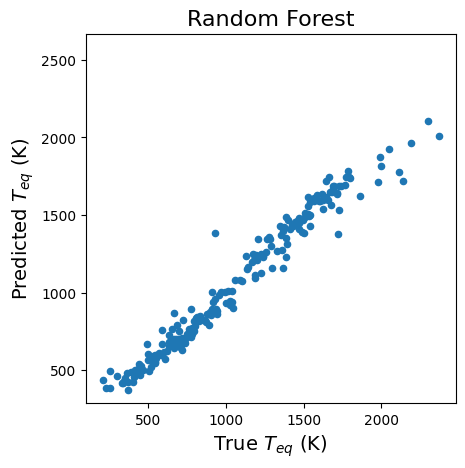

In [213]:
# Use the model to predict the equilibrium temperature values and plot true vs predicted values
ypred = cross_val_predict(model_RF,features,target, cv = KFold(n_splits=5, shuffle=True, random_state=10))

plt.scatter(target,ypred, s = 20)
plt.xlabel(r'True $T_{eq}$ (K)', fontsize=14)
plt.ylabel(r'Predicted $T_{eq}$ (K)',fontsize=14)
plt.title('Random Forest', fontsize=16)
plt.axis('square')
plt.savefig('rf_check', bbox_inches='tight')

In [233]:
model_RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# XGBoost

In [237]:
# Build XGBoost model
model_XG = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric='mae')
model_XG.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [238]:
# Evaluate initial XGBoost R^2 results to see how the model performed
scores = cross_validate(model_XG, features, target, cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score=True)

print('Train R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(scores['train_score']), np.std(scores['train_score'])))
print('Test R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(scores['test_score']), np.std(scores['test_score'])))

Train R^2 scores: 1.000 +/- 0.000
Test R^2 scores: 0.977 +/- 0.017


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

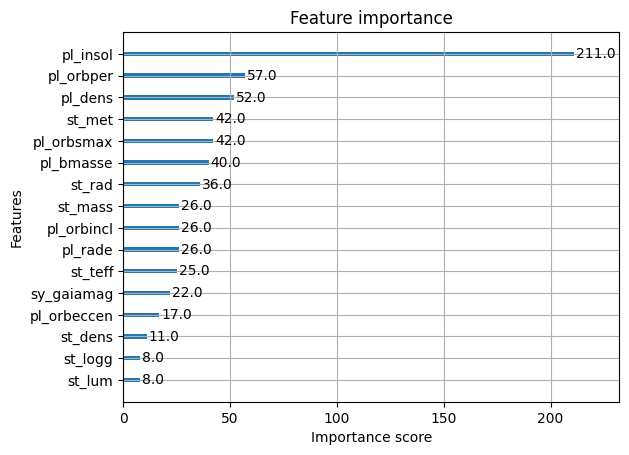

In [239]:
# Investigate feature importance
xgb.plot_importance(model_XG)

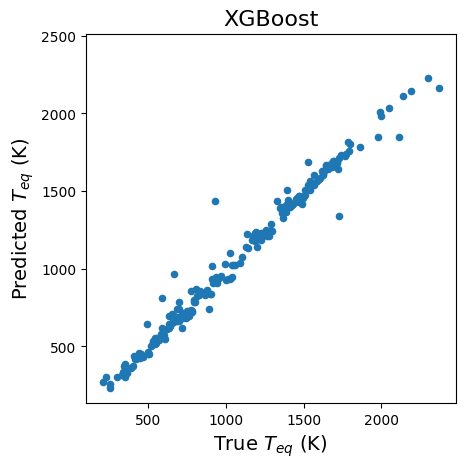

In [240]:
# Predict XGBoost equilibrium temperature values and plot true vs predicted values
ypred = cross_val_predict(model_XG,features,target, cv = KFold(n_splits=5, shuffle=True, random_state=10))

plt.scatter(target,ypred, s = 20)
plt.xlabel(r'True $T_{eq}$ (K)', fontsize=14)
plt.ylabel(r'Predicted $T_{eq}$ (K)',fontsize=14)
plt.title('XGBoost', fontsize=16)
plt.axis('square')
plt.savefig('xg_check', bbox_inches='tight')

In [241]:
# Find RMSE and MAE for both models
# Random Forest
rf_pred = model_RF.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

# XGBoost
xgb_pred = model_XG.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

Random Forest RMSE: 82.34675576332195
Random Forest MAE: 52.40630232558147
XGBoost RMSE: 38.00723356449581
XGBoost MAE: 30.239953684252363


# Hyperparameter Tuning

In [242]:
# Perform grid searches for both the Random Forest model and the XGBoost model to find the best hyperparameters
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1)

In [243]:
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

In [244]:
print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [245]:
xgb = XGBRegressor(random_state=42)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1)

In [246]:
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

In [247]:
print("Best XGB params:", xgb_grid.best_params_)

Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [248]:
def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} MAE: {mae:.2f}")
    return rmse, mae

evaluate(best_rf, X_test, y_test, "Random Forest")
evaluate(best_xgb, X_test, y_test, "XGBoost")

Random Forest RMSE: 29.64
Random Forest MAE: 23.43
XGBoost RMSE: 38.56
XGBoost MAE: 31.01


(np.float64(38.557214506929036), 31.01324498376181)

# Feature Selection

## 1. Remove correlated features

In [251]:
# Create a correlation matrix to show which features have linear relationships with one another 
# A value of 1 denotes a perfect linear relationship, -1 denotes perfect inverse, and 0 denotes no relationship
corr_matrix = features.corr().abs()
corr_matrix

,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_insol,pl_orbincl,st_teff,st_rad,st_mass,st_met,st_lum,st_logg,st_dens,sy_gaiamag
pl_orbper,1.000000,0.975684,0.027231,0.069364,0.008909,0.389389,0.137133,0.187619,0.095718,0.103255,0.079114,0.014666,0.118042,0.128875,0.092461,0.068060
pl_orbsmax,0.975684,1.000000,0.017788,0.077937,0.007877,0.431803,0.176009,0.240943,0.139491,0.153533,0.121585,0.016873,0.171441,0.181750,0.135952,0.012617
pl_rade,0.027231,0.017788,1.000000,0.286546,0.135697,0.092215,0.519715,0.339477,0.624217,0.488849,0.655017,0.420877,0.604790,0.494335,0.468541,0.343425
pl_bmasse,0.069364,0.077937,0.286546,1.000000,0.137923,0.130804,0.283161,0.134099,0.232187,0.250040,0.288507,0.134188,0.237664,0.223373,0.159530,0.115496
pl_dens,0.008909,0.007877,0.135697,0.137923,1.000000,0.181073,0.020806,0.026300,0.027033,0.319774,0.085725,0.039215,0.100385,0.258892,0.052062,0.051228
pl_orbeccen,0.389389,0.431803,0.092215,0.130804,0.181073,1.000000,0.109988,0.071292,0.164619,0.393027,0.250485,0.123643,0.261211,0.354164,0.174768,0.002776
pl_insol,0.137133,0.176009,0.519715,0.283161,0.020806,0.109988,1.000000,0.694393,0.599766,0.461534,0.619311,0.120980,0.523311,0.422543,0.327275,0.027408
pl_orbincl,0.187619,0.240943,0.339477,0.134099,0.026300,0.071292,0.694393,1.000000,0.342070,0.321461,0.399713,0.189733,0.332669,0.282566,0.245102,0.046712
st_teff,0.095718,0.139491,0.624217,0.232187,0.027033,0.164619,0.599766,0.342070,1.000000,0.746815,0.941878,0.169914,0.950422,0.774560,0.741120,0.266172
st_rad,0.103255,0.153533,0.488849,0.250040,0.319774,0.393027,0.461534,0.321461,0.746815,1.000000,0.879165,0.243453,0.877219,0.956979,0.634746,0.180501


In [252]:
# Find the features that are more than 75% correlated
threshold = 0.75
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, corr_value))

# Print results
print("Highly correlated features to drop:", to_drop)
print('')

for pair in high_corr_pairs:
    print(f"{pair[0]} is highly correlated with {pair[1]} (corr = {pair[2]:.2f})")

Highly correlated features to drop: ['pl_orbsmax', 'st_mass', 'st_lum', 'st_logg', 'st_dens']

pl_orbsmax is highly correlated with pl_orbper (corr = 0.98)
st_mass is highly correlated with st_teff (corr = 0.94)
st_mass is highly correlated with st_rad (corr = 0.88)
st_lum is highly correlated with st_teff (corr = 0.95)
st_lum is highly correlated with st_rad (corr = 0.88)
st_lum is highly correlated with st_mass (corr = 0.96)
st_logg is highly correlated with st_teff (corr = 0.77)
st_logg is highly correlated with st_rad (corr = 0.96)
st_logg is highly correlated with st_mass (corr = 0.87)
st_logg is highly correlated with st_lum (corr = 0.90)
st_dens is highly correlated with st_mass (corr = 0.75)
st_dens is highly correlated with st_lum (corr = 0.82)


In [253]:
# Drop highly correlated features
features_uncorr = features.drop(columns=to_drop)

In [254]:
features_uncorr

,pl_orbper,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_insol,pl_orbincl,st_teff,st_rad,st_met,sy_gaiamag
0,5.745998,1.900000,4.000000,3.200000,0.00000,6.27,89.030,3395.0,0.3026,-0.07,12.73310
1,0.321923,0.699000,0.633000,10.200000,0.06000,579.00,79.890,3522.0,0.4580,-0.01,9.15159
2,2.616235,1.090000,1.750000,7.300000,0.00000,17.30,88.442,3384.0,0.3200,-0.02,11.51090
3,1.467121,1.289000,2.770000,6.660000,0.00086,39.20,89.390,3317.0,0.3243,-0.15,10.09400
4,1.744579,16.477202,6261.219618,8.222423,0.00000,4650.00,79.900,7000.0,1.5600,0.35,12.22280
...,...,...,...,...,...,...,...,...,...,...,...
206,7.133516,10.099292,136.030558,0.730000,0.01630,58.50,89.460,4686.0,0.7580,0.15,11.75380
207,1.011536,1.841000,6.260000,5.470000,0.00000,791.00,88.820,4686.0,0.7580,0.15,11.75380
208,4.233701,16.107305,104.883374,0.135000,0.00000,901.90,83.780,6399.0,1.3470,0.06,11.68260
209,0.788839,15.860708,366.773982,0.506000,0.01260,3320.00,79.080,5616.0,1.0060,0.04,12.10880


## 2. Remove least important features

In [256]:
# Evaluate feature importance
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp)

pl_insol       0.988273
pl_orbincl     0.001552
st_met         0.001337
pl_bmasse      0.001134
st_teff        0.000968
st_mass        0.000918
st_logg        0.000744
st_rad         0.000682
pl_orbeccen    0.000632
sy_gaiamag     0.000605
pl_dens        0.000602
pl_rade        0.000568
st_lum         0.000541
pl_orbsmax     0.000540
st_dens        0.000456
pl_orbper      0.000446
dtype: float64


In [257]:
# Select the top 10 features
# NOTE: I dropped pl_orbsmax, because it was listed as highly correlated to pl_orbper. 
# However, pl_orbper was also dropped due to low importance which means neither of them were included. 
# I later added pl_orbper back so as to not lose both features.
most_imp_feats = []
for feature in features_uncorr:
    if feature == 'pl_orbper':
        most_imp_feats.append(feature)
    elif feat_imp[feature] > 0.0006:
        most_imp_feats.append(feature)

most_imp_feats

['pl_orbper',
 'pl_bmasse',
 'pl_dens',
 'pl_orbeccen',
 'pl_insol',
 'pl_orbincl',
 'st_teff',
 'st_rad',
 'st_met',
 'sy_gaiamag']

In [258]:
features_final = features_uncorr[most_imp_feats]

In [259]:
features_final

,pl_orbper,pl_bmasse,pl_dens,pl_orbeccen,pl_insol,pl_orbincl,st_teff,st_rad,st_met,sy_gaiamag
0,5.745998,4.000000,3.200000,0.00000,6.27,89.030,3395.0,0.3026,-0.07,12.73310
1,0.321923,0.633000,10.200000,0.06000,579.00,79.890,3522.0,0.4580,-0.01,9.15159
2,2.616235,1.750000,7.300000,0.00000,17.30,88.442,3384.0,0.3200,-0.02,11.51090
3,1.467121,2.770000,6.660000,0.00086,39.20,89.390,3317.0,0.3243,-0.15,10.09400
4,1.744579,6261.219618,8.222423,0.00000,4650.00,79.900,7000.0,1.5600,0.35,12.22280
...,...,...,...,...,...,...,...,...,...,...
206,7.133516,136.030558,0.730000,0.01630,58.50,89.460,4686.0,0.7580,0.15,11.75380
207,1.011536,6.260000,5.470000,0.00000,791.00,88.820,4686.0,0.7580,0.15,11.75380
208,4.233701,104.883374,0.135000,0.00000,901.90,83.780,6399.0,1.3470,0.06,11.68260
209,0.788839,366.773982,0.506000,0.01260,3320.00,79.080,5616.0,1.0060,0.04,12.10880


In [260]:
# Split train/test data using new features
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(features_final, target, test_size=0.2, random_state=42)

In [261]:
# Run both models with the best hyperparameters on the smaller set of features
best_rf.fit(X_train_f, y_train_f)
best_xgb.fit(X_train_f, y_train_f)

print("After Feature Selection")
evaluate(best_rf, X_test_f, y_test_f, "RF (Selected Features)")
evaluate(best_xgb, X_test_f, y_test_f, "XGB (Selected Features)")

After Feature Selection
RF (Selected Features) RMSE: 40.53
RF (Selected Features) MAE: 31.60
XGB (Selected Features) RMSE: 45.39
XGB (Selected Features) MAE: 36.03


(np.float64(45.394373067033875), 36.02700975994731)

# 3. Remove insolation flux

In [264]:
# Because insolation flux so highly dominated feature importance (which makes sense as it is directly correlated to equilibrium temp,
# I decided to try running the models without it.
features_final_noinsol = features_final.drop(columns='pl_insol')

In [265]:
features_final_noinsol

,pl_orbper,pl_bmasse,pl_dens,pl_orbeccen,pl_orbincl,st_teff,st_rad,st_met,sy_gaiamag
0,5.745998,4.000000,3.200000,0.00000,89.030,3395.0,0.3026,-0.07,12.73310
1,0.321923,0.633000,10.200000,0.06000,79.890,3522.0,0.4580,-0.01,9.15159
2,2.616235,1.750000,7.300000,0.00000,88.442,3384.0,0.3200,-0.02,11.51090
3,1.467121,2.770000,6.660000,0.00086,89.390,3317.0,0.3243,-0.15,10.09400
4,1.744579,6261.219618,8.222423,0.00000,79.900,7000.0,1.5600,0.35,12.22280
...,...,...,...,...,...,...,...,...,...
206,7.133516,136.030558,0.730000,0.01630,89.460,4686.0,0.7580,0.15,11.75380
207,1.011536,6.260000,5.470000,0.00000,88.820,4686.0,0.7580,0.15,11.75380
208,4.233701,104.883374,0.135000,0.00000,83.780,6399.0,1.3470,0.06,11.68260
209,0.788839,366.773982,0.506000,0.01260,79.080,5616.0,1.0060,0.04,12.10880


In [266]:
# Train/test split with no insolation flux
X_train_noinsol, X_test_noinsol, y_train_noinsol, y_test_noinsol = train_test_split(features_final_noinsol, target, test_size=0.2, random_state=42)

In [267]:
# Model evaluation
best_rf.fit(X_train_noinsol, y_train_noinsol)
best_xgb.fit(X_train_noinsol, y_train_noinsol)

print("Feature Selection WITHOUT pl_insol")
evaluate(best_rf, X_test_noinsol, y_test_noinsol, "RF (Selected Features)")
evaluate(best_xgb, X_test_noinsol, y_test_noinsol, "XGB (Selected Features)")

Feature Selection WITHOUT pl_insol
RF (Selected Features) RMSE: 111.76
RF (Selected Features) MAE: 87.60
XGB (Selected Features) RMSE: 84.35
XGB (Selected Features) MAE: 66.85


(np.float64(84.35430709008362), 66.8487595669059)

In [270]:
# The scores are much worse without it, so I needed to find a way to offset the loss of such a huge feature.
# Feature engineering to make up for lost pl_insol
X_fe = features_final_noinsol.copy() # Copied to avoid editing the original

# 1. Luminosity proxy
X_fe['lum_proxy'] = (X_fe['st_rad']**2) * (X_fe['st_teff']**4)

# 2. Log transform
X_fe['log_lum'] = np.log(X_fe['lum_proxy'] + 1)

# 3. Brightness proxy
X_fe['brightness_proxy'] = 10 ** (-0.4 * X_fe['sy_gaiamag'])

# 4. Distance proxy
X_fe['inv_distance'] = 1 / (X_fe['pl_orbper'] ** (4/3) + 1e-6)

In [269]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, target, test_size=0.2, random_state=42)

In [271]:
# I re-ran the grid search for best hyperparameters using the new train/test split
rf_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1)

In [272]:
rf_grid.fit(X_train_fe, y_train_fe)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [273]:
best_rf_fe = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [274]:
xgb_param_grid = {
    'n_estimators': [400, 600],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1)

In [275]:
xgb_grid.fit(X_train_fe, y_train_fe)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05], 'max_depth': [4, 6, ...], 'n_estimators': [400, 600], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [276]:
best_xgb_fe = xgb_grid.best_estimator_

print("Best XGB params:", xgb_grid.best_params_)

Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 600, 'subsample': 0.8}


In [277]:
# Evaluating the model with new hyperparameters
print("Feature Engineered and Tuned (No Insolation)")

evaluate(best_rf_fe, X_test_fe, y_test_fe, "RF (Engineered)")
evaluate(best_xgb_fe, X_test_fe, y_test_fe, "XGB (Engineered)")

Feature Engineered and Tuned (No Insolation)
RF (Engineered) RMSE: 122.00
RF (Engineered) MAE: 83.25
XGB (Engineered) RMSE: 75.12
XGB (Engineered) MAE: 58.63


(np.float64(75.12054998462976), 58.62896416242732)

In [278]:
rf_scores = cross_validate(best_rf_fe, X_fe, target, cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score=True)

print('Train R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(rf_scores['train_score']), np.std(rf_scores['train_score'])))
print('Test R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(rf_scores['test_score']), np.std(rf_scores['test_score'])))

Train R^2 scores: 0.989 +/- 0.001
Test R^2 scores: 0.924 +/- 0.016


In [279]:
xg_scores = cross_validate(best_xgb_fe, X_fe, target, cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score=True)

print('Train R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(xg_scores['train_score']), np.std(xg_scores['train_score'])))
print('Test R^2 scores: {:.3f} +/- {:.3f}'.format(np.mean(xg_scores['test_score']), np.std(xg_scores['test_score'])))

Train R^2 scores: 1.000 +/- 0.000
Test R^2 scores: 0.957 +/- 0.004
